Roll Number: CH.SC.U4CSE24123
Name: M A Kaushik
K-MEANS CLUSTERING 1

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
df = sns.load_dataset('geyser')
df.head()

,duration,waiting,kind
0,3.600,79,long
1,1.800,54,short
2,3.333,74,long
3,2.283,62,short
4,4.533,85,long


In [ ]:
print(df.shape)
print(df.info())
df.describe()

(272, 3)
<class 'pandas.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   duration  272 non-null    float64
 1   waiting   272 non-null    int64  
 2   kind      272 non-null    str    
dtypes: float64(1), int64(1), str(1)
memory usage: 6.5 KB
None


,duration,waiting
count,272.000000,272.000000
mean,3.487783,70.897059
std,1.141371,13.594974
min,1.600000,43.000000
25%,2.162750,58.000000
50%,4.000000,76.000000
75%,4.454250,82.000000
max,5.100000,96.000000


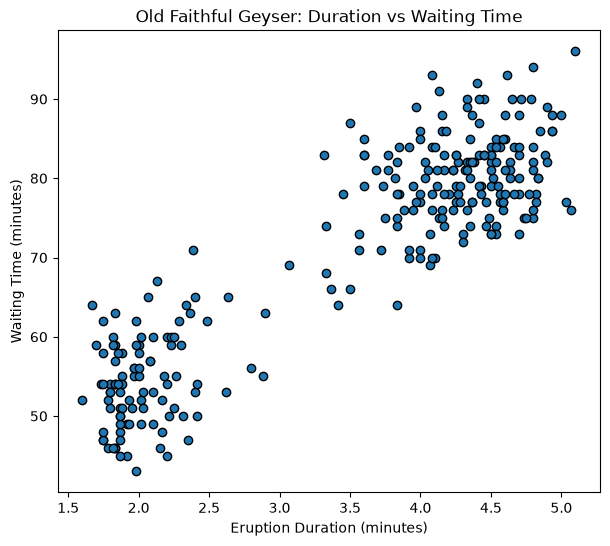

In [ ]:
X = df[['duration', 'waiting']].values
plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], edgecolors='k')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.title('Old Faithful Geyser: Duration vs Waiting Time')
plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

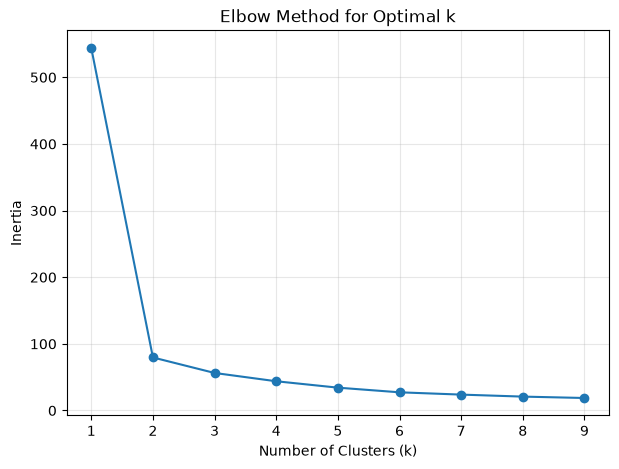

In [ ]:
inertias = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)
df.head()

,duration,waiting,kind,cluster
0,3.600,79,long,0
1,1.800,54,short,1
2,3.333,74,long,0
3,2.283,62,short,1
4,4.533,85,long,0


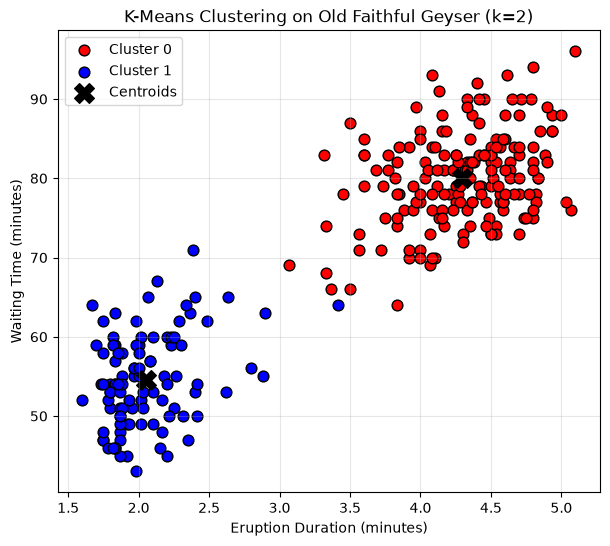

In [ ]:
plt.figure(figsize=(7, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange']
for cluster in range(k):
    subset = df[df['cluster'] == cluster]
    plt.scatter(subset['duration'], subset['waiting'],
                c=colors[cluster], label=f'Cluster {cluster}', edgecolors='k', s=60)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Eruption Duration (minutes)')
plt.ylabel('Waiting Time (minutes)')
plt.title(f'K-Means Clustering on Old Faithful Geyser (k={k})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
cluster_summary = df.groupby('cluster')[['duration', 'waiting']].mean()
print("Cluster centers (mean duration & waiting time):")
print(cluster_summary)

Cluster centers (mean duration & waiting time):
         duration    waiting
cluster                     
0        4.296328  80.080460
1        2.052204  54.591837
